In [5]:
"""
Compute a monthly climatology from a BATS pigment dataset.

This script downloads (or reads locally) a CSV file of high‑performance
liquid chromatography (HPLC) and fluorometric pigment measurements from
the Bermuda Atlantic Time‑series Study (BATS).  It processes the data
into a seasonal climatology on a fixed depth grid and returns an
``xarray.Dataset`` with dimensions ``month`` and ``depth``.  Each pigment
column is averaged across all years for each month and depth.

The code is designed to be flexible: provide a URL to the dataset when
calling ``build_pigment_climatology`` or pass a local file path.  Any
columns beginning with ``p`` (but not ``QF``) are treated as pigment
concentrations.  Quality flag columns (prefixed with ``QF_``) are
ignored.  The date is parsed from a column named ``ISO_DateTime_UTC``
(format ``YYYY‑MM‑DDTHH:MMZ``).  Depth is read from the ``Depth``
column and snapped to the nearest value in ``STANDARD_DEPTHS`` within
``DEPTH_TOLERANCE``.

Example usage:

    from bats_pigments_climatology import build_pigment_climatology
    ds = build_pigment_climatology(
        url_or_path='https://datadocs.bco-dmo.org/dataset/893521/file/VJE0JR1flLQOMR/893521_v9_bats_pigments.csv'
    )
    print(ds)
    ds.to_netcdf('bats_pigments_monthly_climatology.nc')

Requirements:

* pandas
* numpy
* xarray
* requests (only if downloading from HTTP)

"""

from __future__ import annotations

import io
import warnings
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import xarray as xr
import requests

__all__ = [
    'STANDARD_DEPTHS',
    'DEPTH_TOLERANCE',
    'download_pigment_data',
    'preprocess_pigments',
    'compute_monthly_climatology',
    'build_pigment_climatology',
]

import os
wrkdir = "/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations"
os.chdir(wrkdir)
os.getcwd()


'/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations'

In [6]:

# Define a standard depth grid (in metres) appropriate for the BATS pigment
# dataset.  BATS pigment casts usually sample 12 depths between 0 and
# roughly 250 m.  Here we adopt a 10 m resolution up to 300 m, which is
# flexible enough to accommodate occasional deeper samples.  Adjust this
# array if you wish to alter the vertical resolution or range.
STANDARD_DEPTHS: np.ndarray = np.arange(0, 301, 20)

# Maximum difference (in metres) allowed when matching observed depths to
# ``STANDARD_DEPTHS``.  If the absolute difference between an observed
# depth and the nearest standard depth exceeds this value, the sample is
# discarded.  Increase this tolerance to retain more data, or decrease it
# to enforce stricter matching.
DEPTH_TOLERANCE: float = 10.0


### DOWNLOAD

In [7]:
def download_pigment_data(url_or_path: str) -> pd.DataFrame:
    """Download or read the pigment dataset into a DataFrame.

    Parameters
    ----------
    url_or_path : str
        Either an HTTP(S) URL pointing to a CSV file or a local file path.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the pigment data.  Returns an empty
        DataFrame if the file cannot be read or downloaded.
    """
    try:
        if url_or_path.startswith(('http://', 'https://')):
            # Download via HTTP
            resp = requests.get(url_or_path, timeout=60)
            resp.raise_for_status()
            content = resp.content
            return pd.read_csv(io.BytesIO(content), dtype=str)
        else:
            # Local file
            return pd.read_csv(url_or_path, dtype=str)
    except Exception as exc:
        warnings.warn(f"Failed to load pigment data from {url_or_path}: {exc}")
        return pd.DataFrame()

### PROCESS

In [8]:
def preprocess_pigments(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocess the raw pigment DataFrame.

    Steps include:

    * Parse dates from the ``ISO_DateTime_UTC`` column.
    * Extract the month index (1–12).
    * Convert the ``Depth`` column to a float and snap it to the
      ``STANDARD_DEPTHS`` grid if within ``DEPTH_TOLERANCE``.
    * Select pigment concentration columns (names starting with ``p`` but
      not ``QF``) and convert them to numeric values.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw pigment dataset as returned by ``download_pigment_data``.

    Returns
    -------
    pandas.DataFrame
        Tidy DataFrame containing columns ``month``, ``depth`` and one
        column per pigment variable.  Observations without valid dates or
        depths are dropped.
    """
    if df.empty:
        return df

    # Ensure ISO_DateTime_UTC exists
    if 'ISO_DateTime_UTC' not in df.columns:
        warnings.warn("Column 'ISO_DateTime_UTC' not found in pigment data; cannot parse dates.")
        return pd.DataFrame()

    # Parse ISO 8601 date strings into pandas datetime; errors set to NaT
    df['datetime'] = pd.to_datetime(df['ISO_DateTime_UTC'], errors='coerce')
    df.dropna(subset=['datetime'], inplace=True)
    df['month'] = df['datetime'].dt.month

    # Convert depth column to numeric
    if 'Depth' not in df.columns:
        warnings.warn("Column 'Depth' not found in pigment data; cannot assign depths.")
        return pd.DataFrame()
    df['depth_orig'] = pd.to_numeric(df['Depth'], errors='coerce')
    df.dropna(subset=['depth_orig'], inplace=True)

    # Snap depths to the nearest standard depth
    # Compute indices of nearest standard depth for each sample
    idxs = np.abs(df['depth_orig'].values[:, None] - STANDARD_DEPTHS[None, :]).argmin(axis=1)
    snapped_depths = STANDARD_DEPTHS[idxs]
    # Filter out observations beyond tolerance
    within = np.abs(df['depth_orig'] - snapped_depths) <= DEPTH_TOLERANCE
    df = df.loc[within].copy()
    df['depth'] = snapped_depths[within.values]

    # Identify pigment concentration columns: names beginning with 'p' (case sensitive)
    pigment_cols = [col for col in df.columns if col.startswith('p') and not col.startswith('QF')]
    # Convert selected pigment columns to numeric; coerce errors to NaN
    for col in pigment_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Build tidy DataFrame with month, depth and pigments
    tidy_cols = ['month', 'depth'] + pigment_cols
    return df[tidy_cols]

### CLIMATOLOGY

In [12]:
def compute_monthly_climatology(df: pd.DataFrame, variables: Iterable[str]) -> xr.Dataset:
    """Aggregate pigment data into a monthly climatology.

    Parameters
    ----------
    df : pandas.DataFrame
        Tidy DataFrame produced by ``preprocess_pigments`` with columns
        ``month``, ``depth`` and pigment variables.
    variables : Iterable[str]
        The list of pigment variables to process.  Only variables present
        in ``df`` will be included in the climatology.

    Returns
    -------
    xarray.Dataset
        Dataset with dimensions ``month`` and ``depth``.  Each variable
        contains the mean pigment concentration for that month and depth
        across all years.  Missing combinations are filled with NaN.
    """
    # Determine full coordinate axes
    months = np.arange(1, 13)
    depths = STANDARD_DEPTHS.copy()
    data_vars = {}

    for var in variables:
        if var not in df.columns:
            continue
        # Create pivot table: index=month, columns=depth
        pivot = df.pivot_table(index='month', columns='depth', values=var, aggfunc='mean')
        # Reindex to full months and depths
        pivot = pivot.reindex(index=months, columns=depths)
        data_vars[var] = (('month', 'depth'), pivot.values.astype(float))

    ds = xr.Dataset(
        data_vars=data_vars,
        coords={'month': months, 'depth': depths},
        attrs={'description': 'Monthly climatology of BATS pigment concentrations on a fixed depth grid'}
    )
    return ds


### BUILD

In [15]:
def build_pigment_climatology(url_or_path: str, depth_grid: Optional[np.ndarray] = None) -> xr.Dataset:
    """Download, preprocess and compute a monthly climatology for pigments.

    Parameters
    ----------
    url_or_path : str
        HTTP(S) URL to the CSV file or a local file path.  If the file is
        already available locally, providing the path avoids network
        latency.
    depth_grid : array-like of float, optional
        Override the default ``STANDARD_DEPTHS``.  If supplied, this
        array will replace the global grid used to snap depths and define
        the climatology depth axis.  You may also adjust
        ``DEPTH_TOLERANCE`` globally to match this new grid.

    Returns
    -------
    xarray.Dataset
        Monthly climatology dataset with pigment concentrations.  The
        variable names correspond to the pigment column names in the
        original CSV (e.g., ``p1``, ``p2``, ``p16_Chl``, etc.).
    """
    global STANDARD_DEPTHS
    if depth_grid is not None:
        STANDARD_DEPTHS = np.asarray(depth_grid, dtype=float)

    raw = download_pigment_data(url_or_path)
    tidy = preprocess_pigments(raw)
    if tidy.empty:
        raise RuntimeError("No valid pigment data after preprocessing.")
    # Identify pigment variables from tidy DataFrame
    vars_to_process = [col for col in tidy.columns if col not in ('month', 'depth')]
    return compute_monthly_climatology(tidy, vars_to_process)




### call

In [37]:
%%time

link = "https://datadocs.bco-dmo.org/dataset/893521/file/VJE0JR1flLQOMR/893521_v9_bats_pigments.csv"
ds = build_pigment_climatology(link)
print(ds)


<xarray.Dataset> Size: 32kB
Dimensions:   (month: 12, depth: 16)
Coordinates:
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * depth     (depth) int64 128B 0 20 40 60 80 100 ... 200 220 240 260 280 300
Data variables: (12/21)
    p1        (month, depth) float64 2kB 10.54 10.92 15.42 ... 0.1538 nan nan
    p2        (month, depth) float64 2kB 2.556 4.31 2.75 ... 0.3333 nan nan
    p3        (month, depth) float64 2kB 18.25 23.37 22.88 ... 0.1538 nan nan
    p4        (month, depth) float64 2kB 1.271 1.367 1.515 ... 0.1538 nan nan
    p5        (month, depth) float64 2kB 19.38 23.35 23.33 ... 0.2692 nan nan
    p6        (month, depth) float64 2kB 6.771 7.551 7.515 ... 0.1538 nan nan
    ...        ...
    p16_Chl   (month, depth) float64 2kB 0.1654 0.1811 0.1874 ... nan nan
    p17_Phae  (month, depth) float64 2kB 0.04188 0.05244 0.05619 ... nan nan
    p18       (month, depth) float64 2kB 1.103 0.8214 0.9474 ... 0.1905 nan nan
    p19       (month, depth) float64 2kB 39.

### COMPUTE FRACTION MICRO

In [39]:
%%time

import numpy as np
import pandas as pd

def add_pigment_size_fractions(df):
    """
    Adds pigment-derived micro-, nano-, and pico-phytoplankton fractions
    using the diagnostic pigment method of Vidussi/Uitz.

    Assumes pigment columns are in ng/kg:
        p4  = Peridinin
        p5  = 19'-Butanoyloxyfucoxanthin
        p6  = Fucoxanthin
        p7  = 19'-Hexanoyloxyfucoxanthin
        p10 = Alloxanthin
        p12 = Zeaxanthin + Lutein
        p13 = Chlorophyll b
        p14 = HPLC Chlorophyll a
    """

    df = df.copy()

    pigment_vars = ["p4", "p5", "p6", "p7", "p10", "p12", "p13", "p14"]

    for var in pigment_vars:
        if var not in ds:
            raise KeyError(f"Missing required pigment variable: {var}")

        # Remove negative values
        ds[var] = ds[var].where(ds[var] >= 0)

        # Apply QC if present
        qf = f"QF_{var}"
        if qf in ds:
            ds[var] = ds[var].where(ds[qf] == 2)

    perid = df["p4"]
    but   = df["p5"]
    fuco  = df["p6"]
    hex_  = df["p7"]
    allo  = df["p10"]
    zea   = df["p12"]
    chlb  = df["p13"]
    chla  = df["p14"]

    micro_dp = 1.41 * fuco + 1.41 * perid
    nano_dp  = 1.27 * hex_ + 0.35 * but + 0.60 * allo
    pico_dp  = 0.86 * zea + 1.01 * chlb

    total_dp = micro_dp + nano_dp + pico_dp

    df["micro_dp"] = micro_dp
    df["nano_dp"] = nano_dp
    df["pico_dp"] = pico_dp
    df["total_diagnostic_pigments"] = total_dp

    df["micro_fraction"] = micro_dp / total_dp
    df["nano_fraction"] = nano_dp / total_dp
    df["pico_fraction"] = pico_dp / total_dp

    # Optional chlorophyll-equivalent biomass estimates
    df["micro_chla_est"] = df["micro_fraction"] * chla
    df["nano_chla_est"] = df["nano_fraction"] * chla
    df["pico_chla_est"] = df["pico_fraction"] * chla

    return df

ds = add_pigment_size_fractions(ds)
print(ds)


<xarray.Dataset> Size: 48kB
Dimensions:                    (month: 12, depth: 16)
Coordinates:
  * month                      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * depth                      (depth) int64 128B 0 20 40 60 ... 240 260 280 300
Data variables: (12/31)
    p1                         (month, depth) float64 2kB 10.54 10.92 ... nan
    p2                         (month, depth) float64 2kB 2.556 4.31 ... nan nan
    p3                         (month, depth) float64 2kB 18.25 23.37 ... nan
    p4                         (month, depth) float64 2kB 1.271 1.367 ... nan
    p5                         (month, depth) float64 2kB 19.38 23.35 ... nan
    p6                         (month, depth) float64 2kB 6.771 7.551 ... nan
    ...                         ...
    micro_fraction             (month, depth) float64 2kB 0.09121 ... nan
    nano_fraction              (month, depth) float64 2kB 0.5266 0.5114 ... nan
    pico_fraction              (month, depth) float64 2kB 0.382

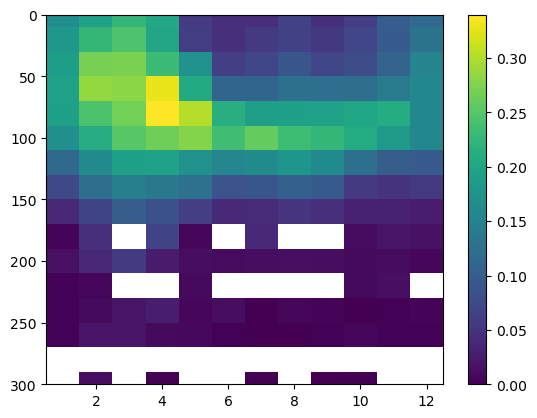

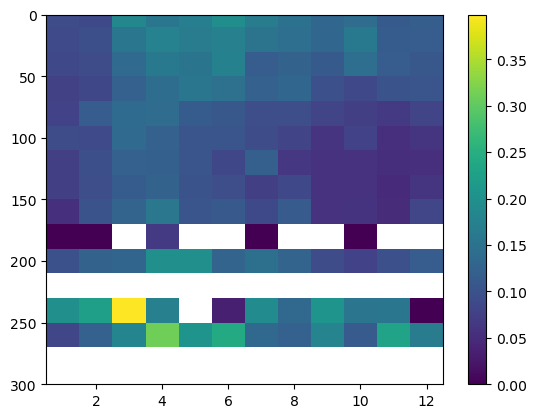

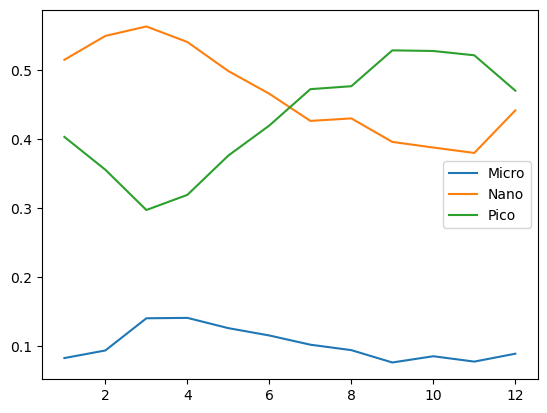

In [45]:
import matplotlib.pyplot as plt

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['p16_Chl'].T)
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['micro_fraction'].T)
plt.ylim(300,0)
plt.colorbar()

microChl = ds['micro_fraction'] * ds['p14'] / ds['p14'].sum(dim='depth')
nanoChl = ds['nano_fraction'] * ds['p14'] / ds['p14'].sum(dim='depth')
picoChl = ds['pico_fraction'] * ds['p14'] / ds['p14'].sum(dim='depth')


plt.figure()
plt.plot(ds.coords['month'], microChl.sum(dim='depth'), label='Micro')
plt.plot(ds.coords['month'], nanoChl.sum(dim='depth'), label='Nano')
plt.plot(ds.coords['month'], picoChl.sum(dim='depth'), label='Pico')
plt.legend()



### SAVE

In [46]:
%%time
    
ds.to_netcdf('./bats_pigments_monthly_climatology.nc')

CPU times: user 268 ms, sys: 169 ms, total: 437 ms
Wall time: 2.27 s
